In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

!gdown 1Q9UJtrN_v_dS-garl5gQ1I_SotGhye_1
!gdown 1HOFWUAMFlYbd-gk1B2IyV2-hXDZI7gKR
!gdown 1b7_yRRBs3s3atp1WQHN2GU577vxY8u_h

Downloading...
From: https://drive.google.com/uc?id=1Q9UJtrN_v_dS-garl5gQ1I_SotGhye_1
To: /content/movies.csv
100% 516k/516k [00:00<00:00, 126MB/s]
Downloading...
From: https://drive.google.com/uc?id=1HOFWUAMFlYbd-gk1B2IyV2-hXDZI7gKR
To: /content/ratings.csv
100% 2.48M/2.48M [00:00<00:00, 23.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1b7_yRRBs3s3atp1WQHN2GU577vxY8u_h
To: /content/users.csv
100% 16.8k/16.8k [00:00<00:00, 46.8MB/s]


In [ ]:
movies = pd.read_csv('movies.csv')

In [ ]:
ratings = pd.read_csv('ratings.csv')

In [ ]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
# timestamp is in Unix epoch time (seconds since Jan 1, 1970, UTC).
ratings.head()

,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523


In [ ]:
len(movies)

10329

In [ ]:
ratings['userId'].nunique()

668

In [ ]:
ratings.movieId.value_counts()

,count
movieId,
296,325
356,311
318,308
480,294
593,290
...,...
133583,1
132961,1
132883,1


In [ ]:
select_movies = ratings.movieId.value_counts().head(1000).index.to_list()

In [ ]:
movies = movies[movies['movieId'].isin(select_movies)]
ratings = ratings[ratings['movieId'].isin(select_movies)]

In [ ]:
len(movies)

1000

In [ ]:
len(ratings)

63250

In [ ]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller


In [ ]:
movies['genres'] = movies['genres'].str.split('|')

In [ ]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"
4,5,Father of the Bride Part II (1995),[Comedy]
5,6,Heat (1995),"[Action, Crime, Thriller]"


In [ ]:
movies['genres'].head()

,genres
0,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,"[Adventure, Children, Fantasy]"
2,"[Comedy, Romance]"
4,[Comedy]
5,"[Action, Crime, Thriller]"


In [ ]:
movies = movies.explode('genres')

In [ ]:
movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure
0,1,Toy Story (1995),Animation
0,1,Toy Story (1995),Children
0,1,Toy Story (1995),Comedy
0,1,Toy Story (1995),Fantasy
...,...,...,...
10005,112852,Guardians of the Galaxy (2014),Adventure
10005,112852,Guardians of the Galaxy (2014),Sci-Fi
10089,116797,The Imitation Game (2014),Drama
10089,116797,The Imitation Game (2014),Thriller


In [ ]:
movies = movies.pivot(index='movieId', columns='genres', values='title')

In [ ]:
movies.head()

genres,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieId,,,,,,,,,,,,,,,,,,,
1,NaN,Toy Story (1995),Toy Story (1995),Toy Story (1995),Toy Story (1995),NaN,NaN,NaN,Toy Story (1995),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Jumanji (1995),NaN,Jumanji (1995),NaN,NaN,NaN,NaN,Jumanji (1995),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,Grumpier Old Men (1995),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Grumpier Old Men (1995),NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,Father of the Bride Part II (1995),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Heat (1995),NaN,NaN,NaN,NaN,Heat (1995),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Heat (1995),NaN,NaN


In [ ]:
movies = ~movies.isna()

In [ ]:
movies

genres,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieId,,,,,,,,,,,,,,,,,,,
1,False,True,True,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False
5,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109374,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False
109487,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False
111759,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False


In [ ]:
movies = movies.astype(int)

In [ ]:
movies

genres,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieId,,,,,,,,,,,,,,,,,,,
1,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
5,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109374,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
109487,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0
111759,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0


In [ ]:
ratings

,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523
...,...,...,...,...
105148,668,109374,4.0,1415763807
105151,668,109487,4.0,1415421771
105185,668,111759,3.0,1413728719
105205,668,112852,4.0,1433992065


In [ ]:
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year'] = ratings['timestamp'].dt.year
ratings['month'] = ratings['timestamp'].dt.month
ratings['dayofweek'] = ratings['timestamp'].dt.dayofweek
ratings['hour'] = ratings['timestamp'].dt.hour

In [ ]:
ratings

,userId,movieId,rating,timestamp,year,month,dayofweek,hour
0,1,16,4.0,2008-08-05 00:56:33,2008,8,1,0
1,1,24,1.5,2008-08-05 00:23:27,2008,8,1,0
2,1,32,4.0,2008-08-05 00:30:46,2008,8,1,0
3,1,47,4.0,2008-08-05 00:35:56,2008,8,1,0
4,1,50,4.0,2008-08-05 00:35:23,2008,8,1,0
...,...,...,...,...,...,...,...,...
105148,668,109374,4.0,2014-11-12 03:43:27,2014,11,2,3
105151,668,109487,4.0,2014-11-08 04:42:51,2014,11,5,4
105185,668,111759,3.0,2014-10-19 14:25:19,2014,10,6,14
105205,668,112852,4.0,2015-06-11 03:07:45,2015,6,3,3


In [ ]:
from sklearn.model_selection import train_test_split

ratings = ratings.sort_values("timestamp")
train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.2,
    shuffle=False  # IMPORTANT: keeps temporal order
)

In [ ]:
train_ratings.head()

,userId,movieId,rating,timestamp,year,month,dayofweek,hour
44838,312,588,4.0,1996-04-03 20:55:54,1996,4,2,20
44831,312,344,4.0,1996-04-03 20:55:54,1996,4,2,20
44805,312,160,2.0,1996-04-03 20:55:54,1996,4,2,20
44804,312,153,4.0,1996-04-03 20:55:54,1996,4,2,20
44803,312,150,5.0,1996-04-03 20:55:54,1996,4,2,20


In [ ]:
test_ratings.head()

,userId,movieId,rating,timestamp,year,month,dayofweek,hour
1518,20,48780,4.0,2010-11-14 18:09:11,2010,11,6,18
1528,20,63082,3.5,2010-11-14 18:09:53,2010,11,6,18
1527,20,59369,4.0,2010-11-14 18:10:17,2010,11,6,18
1531,20,68954,4.0,2010-11-14 18:10:49,2010,11,6,18
1504,20,6539,4.0,2010-11-14 18:17:04,2010,11,6,18


In [ ]:
user_agg_features = train_ratings.groupby('userId').agg(
    user_mean_rating = ('rating', 'mean'),
    user_median_rating = ('rating', 'median'),
    user_rating_std = ('rating', 'std'),
    user_rating_count = ('rating', 'count'),
    user_min_rating=('rating', 'min'),
    user_max_rating=('rating', 'max')
).reset_index()

In [ ]:
user_agg_features

,userId,user_mean_rating,user_median_rating,user_rating_std,user_rating_count,user_min_rating,user_max_rating
0,1,3.691589,4.0,1.072039,107,0.5,5.0
1,2,3.923077,4.0,0.844894,26,2.0,5.0
2,3,3.806452,4.0,0.826581,62,3.0,5.0
3,4,4.147059,4.0,0.868430,68,1.0,5.0
4,8,3.800000,4.0,1.078720,45,1.0,5.0
...,...,...,...,...,...,...,...
518,663,4.000000,4.0,0.780189,24,3.0,5.0
519,665,3.554348,3.5,0.652369,92,2.0,5.0
520,666,3.626984,4.0,1.231156,126,1.0,5.0
521,667,3.807692,4.0,0.641606,65,2.0,5.0


In [ ]:
user_time_based_feats = train_ratings.groupby('userId').agg(
    avg_time_gap_user=('timestamp', lambda x: x.sort_values().diff().dt.total_seconds().mean()),
    ratings_per_month_user=('month', lambda x: len(x) / ratings['month'].nunique())
).reset_index()

In [ ]:
user_time_based_feats

,userId,avg_time_gap_user,ratings_per_month_user
0,1,20.150943,8.916667
1,2,7.840000,2.166667
2,3,11.704918,5.166667
3,4,28.731343,5.666667
4,8,33.431818,3.750000
...,...,...,...
518,663,121.260870,2.000000
519,665,9808.527473,7.666667
520,666,33.104000,10.500000
521,667,12545.812500,5.416667


In [ ]:
movie_agg_features = train_ratings.groupby('movieId').agg(
    movie_mean_rating=('rating', 'mean'),
    movie_median_rating=('rating', 'median'),
    movie_rating_std=('rating', 'std'),
    movie_rating_count=('rating', 'count'),
    movie_min_rating=('rating', 'min'),
    movie_max_rating=('rating', 'max')
).reset_index()
movie_agg_features['movie_rating_std'] = movie_agg_features['movie_rating_std'].fillna(0)

In [ ]:
movie_time_based_feats = train_ratings.groupby('movieId').agg(
    rating_span_days_movie=('timestamp', lambda x: (x.max() - x.min()).days + 1),
    avg_time_gap_movie=('timestamp', lambda x: x.sort_values().diff().dt.total_seconds().mean()),
    rating_frequency_movie=('movieId', 'count')
).reset_index()

In [ ]:
train_df = train_ratings[['userId','movieId','rating']].copy()

In [ ]:
train_df = train_df.merge(user_agg_features,on='userId',how='left')
train_df = train_df.merge(user_time_based_feats,on='userId',how='left')
train_df = train_df.merge(movie_agg_features,on='movieId',how='left')
train_df = train_df.merge(movie_time_based_feats,on='movieId',how='left')
train_df = train_df.merge(movies,on='movieId',how='left')

In [ ]:
test_df = test_ratings[['userId','movieId','rating']].copy()
test_df = test_df.merge(movies,on='movieId',how='left')
test_df = test_df.merge(user_agg_features,on='userId',how='left')
test_df = test_df.merge(user_time_based_feats,on='userId',how='left')
test_df = test_df.merge(movie_agg_features,on='movieId',how='left')
test_df = test_df.merge(movie_time_based_feats,on='movieId',how='left')

In [ ]:
train_df

,userId,movieId,rating,user_mean_rating,user_median_rating,user_rating_std,user_rating_count,user_min_rating,user_max_rating,avg_time_gap_user,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,312,588,4.0,4.216216,4.0,0.672274,37,2.0,5.0,12.472222,...,0,0,0,1,0,0,0,0,0,0
1,312,344,4.0,4.216216,4.0,0.672274,37,2.0,5.0,12.472222,...,0,0,0,0,0,0,0,0,0,0
2,312,160,2.0,4.216216,4.0,0.672274,37,2.0,5.0,12.472222,...,0,0,0,0,1,0,1,0,0,0
3,312,153,4.0,4.216216,4.0,0.672274,37,2.0,5.0,12.472222,...,0,0,0,0,0,0,0,0,0,0
4,312,150,5.0,4.216216,4.0,0.672274,37,2.0,5.0,12.472222,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50595,20,72998,4.0,3.500000,4.0,1.111438,18,0.5,5.0,89.764706,...,0,0,1,0,0,0,1,0,0,0
50596,20,58559,4.0,3.500000,4.0,1.111438,18,0.5,5.0,89.764706,...,0,0,1,0,0,0,0,0,0,0
50597,20,69481,3.5,3.500000,4.0,1.111438,18,0.5,5.0,89.764706,...,0,0,0,0,0,0,0,1,1,0
50598,20,59315,4.0,3.500000,4.0,1.111438,18,0.5,5.0,89.764706,...,0,0,0,0,0,0,1,0,0,0


In [ ]:
test_df

,userId,movieId,rating,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,ratings_per_month_user,movie_mean_rating,movie_median_rating,movie_rating_std,movie_rating_count,movie_min_rating,movie_max_rating,rating_span_days_movie,avg_time_gap_movie,rating_frequency_movie
0,20,48780,4.0,0,0,0,0,0,0,0,...,1.5,3.790323,4.0,0.727716,31.0,2.0,5.0,1374.0,3.954279e+06,31.0
1,20,63082,3.5,0,0,0,0,0,1,0,...,1.5,3.944444,4.0,0.891556,27.0,2.0,5.0,589.0,1.954418e+06,27.0
2,20,59369,4.0,1,0,0,0,0,1,0,...,1.5,3.269231,3.5,0.970725,13.0,1.5,5.0,617.0,4.437713e+06,13.0
3,20,68954,4.0,0,1,1,1,0,0,0,...,1.5,4.236842,4.0,0.561951,19.0,3.0,5.0,376.0,1.803312e+06,19.0
4,20,6539,4.0,1,1,0,0,1,0,0,...,1.5,3.819767,4.0,0.951509,86.0,0.5,5.0,2532.0,2.573548e+06,86.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12645,114,1089,3.0,0,0,0,0,0,1,0,...,NaN,4.100000,4.0,0.873285,100.0,1.0,5.0,5049.0,4.406374e+06,100.0
12646,114,4896,4.0,0,1,0,1,0,0,0,...,NaN,3.443396,3.5,1.077124,53.0,0.5,5.0,3175.0,5.275264e+06,53.0
12647,114,40815,4.0,0,1,0,0,0,0,0,...,NaN,3.416667,3.5,1.060660,18.0,0.5,5.0,1703.0,8.653246e+06,18.0
12648,114,1259,5.0,0,1,0,0,0,0,0,...,NaN,4.085227,4.0,0.657501,88.0,2.0,5.0,5047.0,5.011327e+06,88.0


In [ ]:
test_df = test_df[train_df.columns]

In [ ]:
train_movies = train_df.pop('movieId')
train_users = train_df.pop('userId')
test_movies = test_df.pop('movieId')
test_users = test_df.pop('userId')

In [ ]:
set(train_df.columns)-set(test_df.columns)

set()

In [ ]:
y_train = train_df.pop('rating')
y_test = test_df.pop('rating')

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# ------------------------
# Build Model
# ------------------------
model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# ------------------------
# Train
# ------------------------
model.fit(train_df, y_train)

# ------------------------
# Predict & Evaluate
# ------------------------
preds = model.predict(test_df)

# Round to nearest 0.5
preds = np.round(preds * 2) / 2

# Clip to valid range
preds = np.clip(preds, 0.5, 5.0)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("Test RMSE:", rmse)

Test RMSE: 1.0412822742674328


In [ ]:
y_test.unique()

array([4. , 3.5, 5. , 4.5, 3. , 2.5, 2. , 1.5, 1. , 0.5])

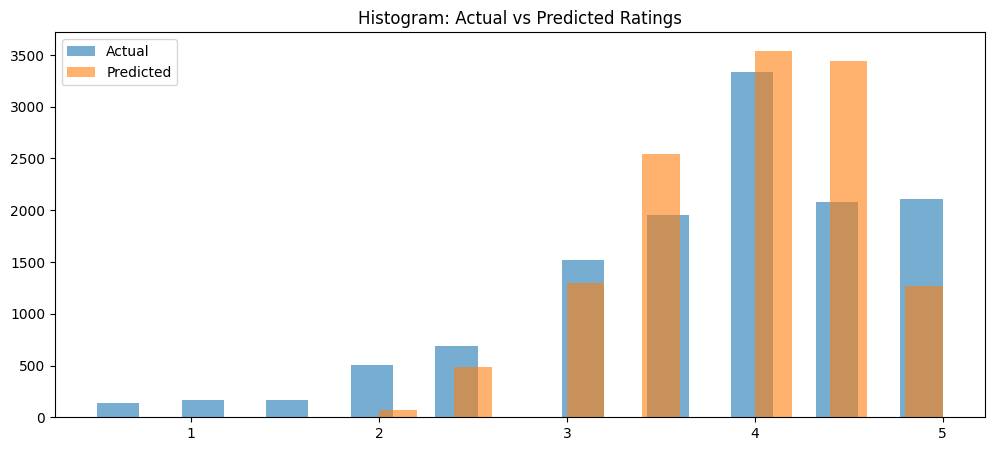

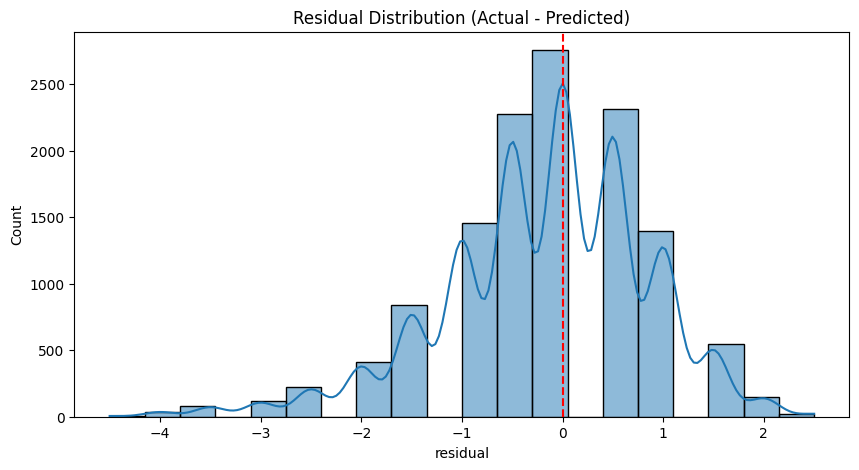


Summary Statistics:
             actual     predicted      residual
count  12650.000000  12650.000000  12650.000000
mean       3.781542      3.964387     -0.182846
std        0.964856      0.655921      1.025144
min        0.500000      1.000000     -4.500000
25%        3.000000      3.500000     -1.000000
50%        4.000000      4.000000      0.000000
75%        4.500000      4.500000      0.500000
max        5.000000      5.000000      2.500000

Residual Mean: -0.18284584980237154
Residual Std: 1.0251435248461362


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
analysis_df = pd.DataFrame({
    "actual": y_test,
    "predicted": preds
})


# -----------------------------
# 2. Histogram Comparison
# -----------------------------
plt.figure(figsize=(12,5))
plt.hist(analysis_df["actual"], bins=20, alpha=0.6, label="Actual")
plt.hist(analysis_df["predicted"], bins=20, alpha=0.6, label="Predicted")
plt.title("Histogram: Actual vs Predicted Ratings")
plt.legend()
plt.show()

# -----------------------------
# 4. Residuals Distribution
# -----------------------------
analysis_df["residual"] = analysis_df["actual"] - analysis_df["predicted"]

plt.figure(figsize=(10,5))
sns.histplot(analysis_df["residual"], bins=20, kde=True)
plt.title("Residual Distribution (Actual - Predicted)")
plt.axvline(0, color='red', linestyle='--')
plt.show()


# -----------------------------
# 5. Summary Statistics
# -----------------------------
print("\nSummary Statistics:")
print(analysis_df.describe())

print("\nResidual Mean:", analysis_df["residual"].mean())
print("Residual Std:", analysis_df["residual"].std())

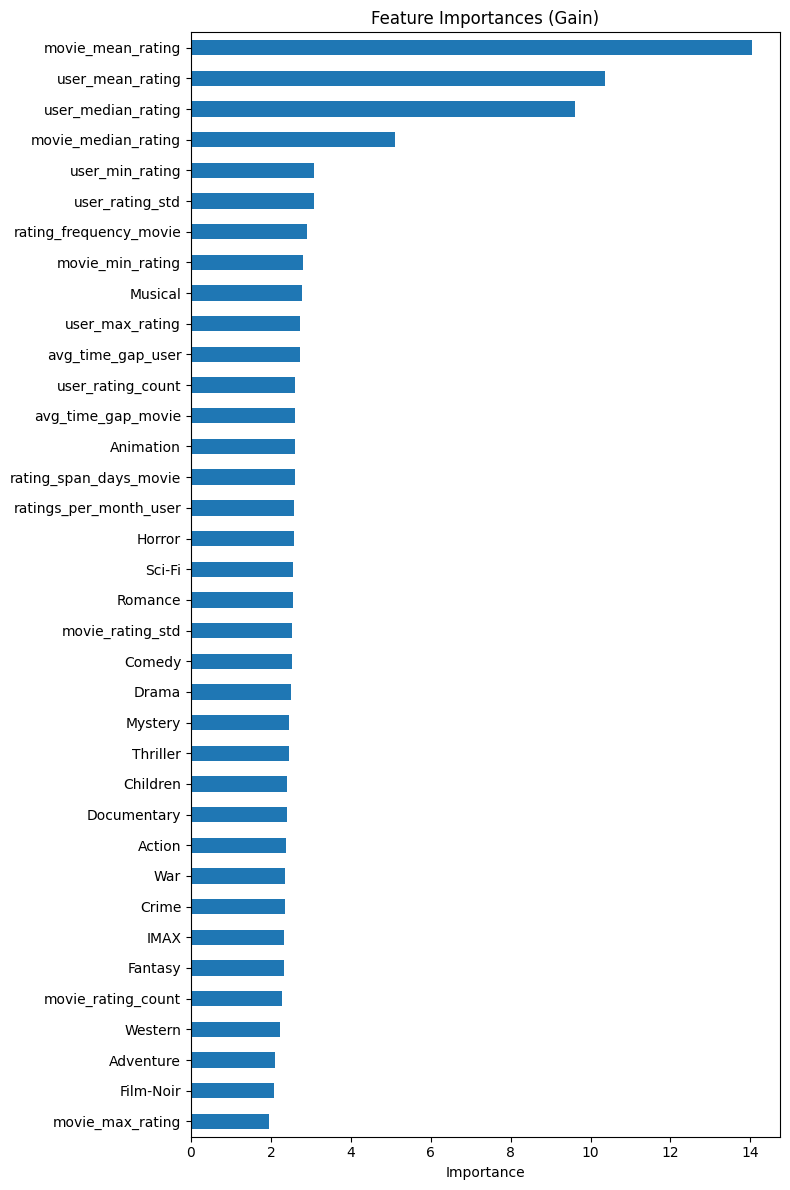

In [ ]:
raw_importances = model.get_booster().get_score(importance_type="gain")

fi = (
    pd.Series(raw_importances)
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 12))
fi.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Feature Importances (Gain)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
df = ratings.rename(columns={"userId":"UserId", "movieId":"ItemId", "rating":"Rating"})
# drop timestamp (not needed for MF)

# 2. Train / test split in time — as before
df = df.sort_values("timestamp").reset_index(drop=True)
split_idx = int(0.8 * len(df))
df = df[["UserId","ItemId","Rating"]]
train_df = df.iloc[:split_idx].reset_index(drop=True)
test_df  = df.iloc[split_idx:].reset_index(drop=True)

In [ ]:
train_df

,UserId,ItemId,Rating
0,312,588,4.0
1,312,349,5.0
2,312,595,3.0
3,312,19,4.0
4,312,39,4.0
...,...,...,...
50595,20,72998,4.0
50596,20,58559,4.0
50597,20,69481,3.5
50598,20,59315,4.0


In [ ]:
test_df

,UserId,ItemId,Rating
0,20,48780,4.0
1,20,63082,3.5
2,20,59369,4.0
3,20,68954,4.0
4,20,6539,4.0
...,...,...,...
12645,114,1089,3.0
12646,114,4896,4.0
12647,114,40815,4.0
12648,114,1259,5.0


In [ ]:
pip install cmfrec

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 4.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached findblas-0.1.26.post1-py3-none-any.whl
  Created wheel for cmfrec: filename=cmfrec-3.5.1.post13-cp312-cp312-linux_x86_64.whl size=5975864 sha256=7f13b7308b01ca5b8ce5ccf8692a16d061478385c96e10f8ea7dd5df8539effa
  Stored in directory: /root/.cache/pip/wheels/46/9d/a7/03614a1633b40dde9aeb6eb12265f9c684feba1e3d82fe05bf
Successfully built cmfrec


In [ ]:
from cmfrec import CMF

In [ ]:
model = CMF(method="als",
            k = 5,          # number of latent factors — you can tune
            lambda_ = 0.1,   # regularization strength — tune this as well
            user_bias = True,
            item_bias = True,
            verbose = True,
            )

In [ ]:
model.fit(X = train_df)

# 4. Predict on TEST: for each (user, item) pair in test_df
users = test_df["UserId"].values
items = test_df["ItemId"].values
preds = model.predict(user = users, item = items)

Starting ALS optimization routine

Updating B ... done
Updating A ... done
	Completed ALS iteration  1

Updating B ... done
Updating A ... done
	Completed ALS iteration  2

Updating B ... done
Updating A ... done
	Completed ALS iteration  3

Updating B ... done
Updating A ... done
	Completed ALS iteration  4

Updating B ... done
Updating A ... done
	Completed ALS iteration  5

Updating B ... done
Updating A ... done
	Completed ALS iteration  6

Updating B ... done
Updating A ... done
	Completed ALS iteration  7

Updating B ... done
Updating A ... done
	Completed ALS iteration  8

Updating B ... done
Updating A ... done
	Completed ALS iteration  9

Updating B ... done
Updating A ... done
	Completed ALS iteration 10

ALS procedure terminated successfully


In [ ]:
model.A_ # user embeddings

array([[-0.04594609,  0.27283567, -0.87099177,  0.34486476,  0.3613064 ],
       [ 0.718156  ,  0.4067536 ,  0.49560395,  0.02565412, -0.28909287],
       [ 0.77023655,  0.1002604 , -0.01332826,  1.1036118 ,  1.2597791 ],
       ...,
       [-0.26784837,  0.53506386, -0.20110442,  0.6729506 , -0.13440566],
       [-1.2035077 , -0.66007733, -0.82858086,  0.20680523, -0.12556508],
       [-1.4557315 ,  0.01296901,  0.1651073 ,  0.75740993, -0.2759814 ]],
      dtype=float32)

In [ ]:
model.B_ # item embeddings

array([[-0.23959246,  0.3835353 , -0.13022242, -1.0097805 ,  0.3581522 ],
       [-0.46717662,  0.00157365, -0.00290891, -0.07272674, -0.3444382 ],
       [-0.6991202 ,  0.07609   ,  0.09198157, -0.8653189 , -0.3492596 ],
       ...,
       [-0.5826209 ,  0.32022387, -0.4194674 ,  0.2638716 ,  0.3229551 ],
       [ 0.16755179,  0.20427811,  0.01842372, -0.07650498, -0.8174887 ],
       [ 0.06506392, -0.00609286,  0.02829024, -0.12258366, -0.01519502]],
      dtype=float32)

In [ ]:
model.user_bias_

array([ 4.85678881e-01,  5.25008380e-01,  1.57359675e-01,  2.19526187e-01,
        3.42184901e-01,  3.38550478e-01,  4.48780470e-02, -5.59747815e-01,
        3.19346189e-01,  3.22124988e-01, -7.13853121e-01, -1.22511126e-01,
       -1.71234444e-01,  3.86174694e-02, -5.69386818e-02, -4.68052536e-01,
        2.83201993e-01,  3.01521510e-01,  6.17447793e-01,  2.80469924e-01,
        4.76721555e-01, -2.65437424e-01, -1.10112071e+00,  2.05019191e-02,
       -2.80889153e-01,  2.39043869e-02,  5.60331464e-01, -2.15153381e-01,
        1.99270621e-02, -1.03504092e-01,  2.68200696e-01,  3.65569800e-01,
        6.65291846e-01,  7.52432421e-02,  8.86157155e-02,  2.35821038e-01,
        1.18184179e-01,  9.06700641e-02,  3.45196635e-01,  5.63998103e-01,
        9.25158262e-02, -1.94095984e-01,  5.88159144e-01,  2.35014930e-01,
       -3.70634884e-01,  1.75563306e-01, -6.34677708e-01,  1.63484514e-01,
       -5.35440326e-01,  5.33837639e-03, -2.23308295e-01, -8.79574567e-02,
       -5.13936520e-01,  

In [ ]:
model.item_bias_

array([-7.07158595e-02,  4.25492711e-02, -3.60357463e-02, -1.21764839e+00,
       -4.89391625e-01, -2.14808464e-01,  4.87806082e-01, -7.69278929e-02,
       -5.91154277e-01,  3.15256625e-01, -7.73177862e-01, -1.41412652e+00,
       -9.37510490e-01, -1.06473958e+00, -9.87049758e-01, -6.98912323e-01,
       -6.78229868e-01,  6.06867112e-02, -4.49280888e-02,  1.90769047e-01,
       -7.51282215e-01, -1.43687636e-01, -2.61373311e-01, -5.19772291e-01,
       -2.89797813e-01, -4.97440189e-01,  3.61950300e-03, -8.01185250e-01,
       -4.03934538e-01, -4.26798642e-01,  5.04381776e-01,  8.22309375e-01,
       -4.45508450e-01, -7.58548141e-01, -4.89818960e-01, -1.28210783e-01,
        1.19072631e-01,  1.71151355e-01, -1.72283813e-01, -9.09351930e-02,
       -1.57879007e+00, -1.75958648e-01, -5.20167232e-01,  5.54904759e-01,
        3.20479989e-01, -2.08186671e-01, -1.31982279e+00,  1.48897931e-01,
       -1.91172004e-01, -4.33992624e-01,  6.90552533e-01, -3.39251041e-01,
       -6.32631719e-01, -

In [ ]:
user_ids = list(train_df['UserId'].unique())
item_ids = list(train_df['ItemId'].unique())

# A_ is (num_users x k)
# B_ is (num_items x k)

user_embeddings = pd.DataFrame(model.A_, index=user_ids)
item_embeddings = pd.DataFrame(model.B_, index=item_ids)

In [ ]:
user_embeddings

,0,1,2,3,4
312,-0.045946,0.272836,-0.870992,0.344865,0.361306
390,0.718156,0.406754,0.495604,0.025654,-0.289093
653,0.770237,0.100260,-0.013328,1.103612,1.259779
245,0.220919,0.399111,0.081241,-0.534716,-0.032734
370,-1.331907,0.310159,-0.134075,-0.514875,-0.605278
...,...,...,...,...,...
557,-0.358487,-0.261871,0.427399,0.044945,-0.437494
53,-1.564131,-0.033504,-0.197404,0.319227,2.220694
360,-0.267848,0.535064,-0.201104,0.672951,-0.134406
621,-1.203508,-0.660077,-0.828581,0.206805,-0.125565


In [ ]:
preds = np.clip(preds, 1.0, 5.0)
# (optional) round to 0.5 steps:
preds = np.round(preds * 2) / 2

# 6. Evaluate with RMSE
rmse = np.sqrt(mean_squared_error(test_df["Rating"], preds))
print("CMF Test RMSE:", rmse)

CMF Test RMSE: 0.9436808765880257


In [ ]:
k = 10

train_users = set(train_df["UserId"].unique())
test_users  = set(test_df["UserId"].unique())

common_users = sorted(test_users & train_users)

rows = []

for user in common_users:

    # Items the user consumed in *training*
    train_items = set(
        train_df[train_df["UserId"] == user]["ItemId"].values
    )

    # Recommended items
    recs = model.topN(user=user, n=k)     # list of itemIds
    recommended = set(recs[:k])

    # Overlap with TRAIN
    seen_hits = len(recommended & train_items)
    seen_overlap = seen_hits / k

    rows.append({
        "UserId": user,
        "Overlap_with_Train@k": seen_overlap,
        "SeenHits": seen_hits
    })

overlap_train_df = pd.DataFrame(rows)
print(overlap_train_df.head())

print("Average Overlap_with_Train@k:", overlap_train_df["Overlap_with_Train@k"].mean())

   UserId  Overlap_with_Train@k  SeenHits
0      17                   0.0         0
1      20                   0.0         0
2      43                   0.0         0
3      55                   0.0         0
4      88                   0.3         3
Average Overlap_with_Train@k: 0.21428571428571427


In [ ]:
import pandas as pd

k = 10

train_users = set(train_df["UserId"].unique())
test_users  = set(test_df["UserId"].unique())

common_users = sorted(test_users & train_users)

rows = []

for user in common_users:

    # Actual interactions in TEST
    actual = set(test_df[test_df["UserId"] == user]["ItemId"].values)

    # Recommended top-k items
    recs = model.topN(user=user, n=k)      # returns [itemId1, itemId2, ...]
    recommended = set(recs[:k])

    # Overlap
    hits = len(actual & recommended)

    rows.append({
        "UserId": user,
        "precision@k": hits / k,
        "Hits": hits
    })

overlap_df = pd.DataFrame(rows)
print(overlap_df)
print("Average precision@k:", overlap_df["precision@k"].mean())


    UserId  precision@k  Hits
0       17          0.0     0
1       20          0.0     0
2       43          0.0     0
3       55          0.0     0
4       88          0.1     1
5      113          0.2     2
6      128          0.1     1
7      137          0.1     1
8      232          0.0     0
9      315          0.1     1
10     402          0.0     0
11     403          0.0     0
12     413          0.2     2
13     451          0.0     0
14     458          0.2     2
15     461          0.2     2
16     493          0.1     1
17     574          0.3     3
18     575          0.2     2
19     590          0.1     1
20     668          0.1     1
Average precision@k: 0.09523809523809526


In [ ]:
actual